In [7]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern theme for our graphs
sns.set_theme(style="darkgrid")

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [8]:
# Load the datasets
try:
    df_base = pd.read_csv("traffic_data.csv")
    df_ml = pd.read_csv("ml_traffic_data.csv")
    print("✅ Datasets loaded successfully!\n")
except FileNotFoundError:
    print("❌ Error: Could not find the CSV files. Make sure they are in the same folder as this notebook.")

# Show the first 5 rows of the AI data
print("--- AI Traffic Data Preview ---")
display(df_ml.head())

✅ Datasets loaded successfully!

--- AI Traffic Data Preview ---


,step,vehicle_count,speed,co2_emission
0,0,1,0.000000,1521.000000
1,1,1,2.029624,3538.964350
2,2,1,3.984050,4087.459401
3,3,2,3.271476,3775.442628
4,4,2,5.029797,4227.069405


In [9]:
# Calculate basic statistics for comparison
base_max_cars = df_base['vehicle_count'].max()
ml_max_cars = df_ml['vehicle_count'].max()

base_avg_speed = df_base['speed'].mean()
ml_avg_speed = df_ml['speed'].mean()

print(f"🔴 Baseline Max Vehicles: {base_max_cars} | Average Speed: {base_avg_speed:.2f} m/s")
print(f"🟢 AI Model Max Vehicles: {ml_max_cars} | Average Speed: {ml_avg_speed:.2f} m/s")

🔴 Baseline Max Vehicles: 203 | Average Speed: 7.04 m/s
🟢 AI Model Max Vehicles: 84 | Average Speed: 8.74 m/s


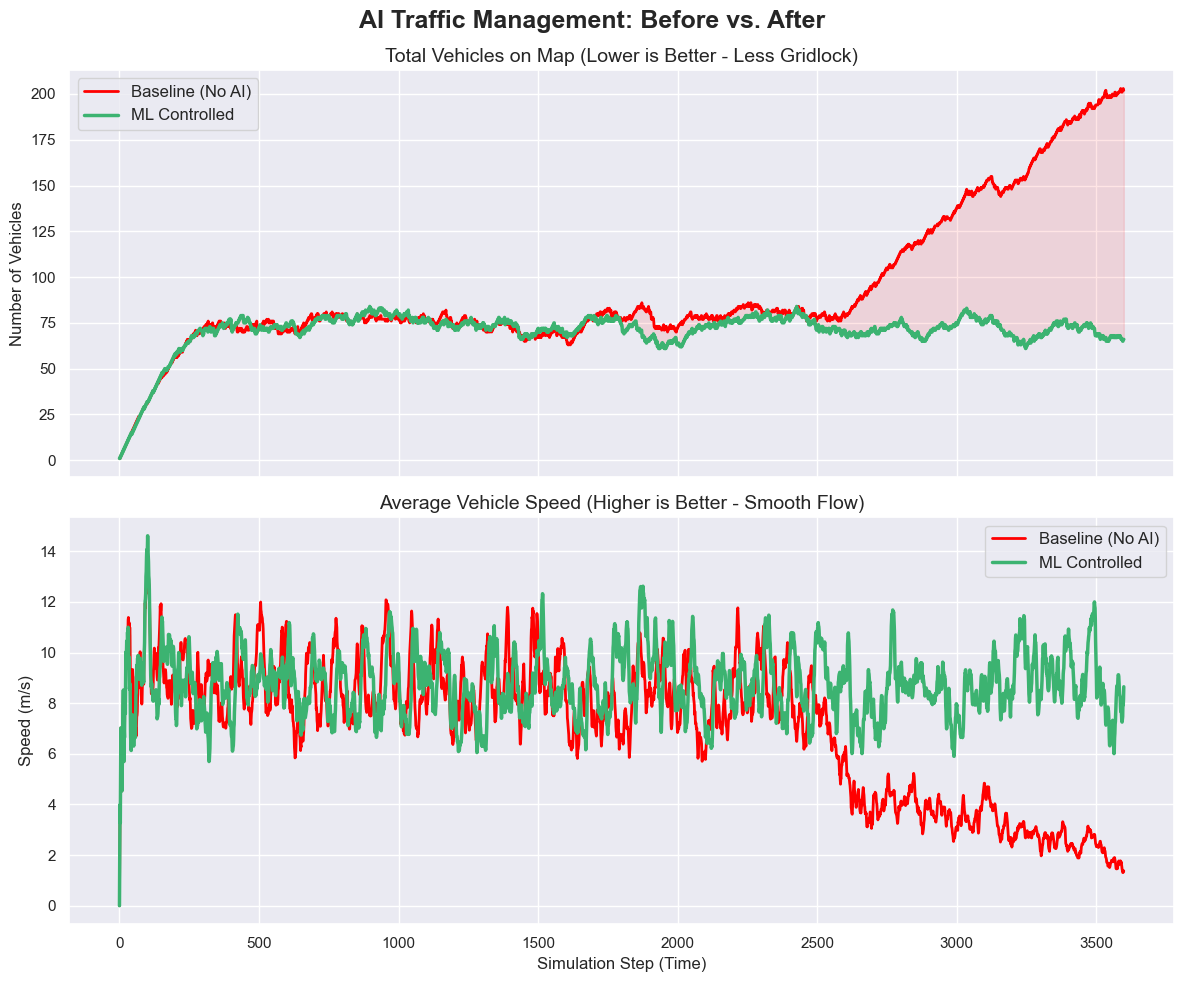

In [10]:
# Set up the figure with 2 subplots (2 rows, 1 column)
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.suptitle('AI Traffic Management: Before vs. After', fontsize=18, fontweight='bold')

# --- PLOT 1: VEHICLE COUNT ---
axes[0].plot(df_base['step'], df_base['vehicle_count'], label='Baseline (No AI)', color='red', linewidth=2)
axes[0].plot(df_ml['step'], df_ml['vehicle_count'], label='ML Controlled', color='mediumseagreen', linewidth=2.5)

axes[0].set_title('Total Vehicles on Map (Lower is Better - Less Gridlock)', fontsize=14)
axes[0].set_ylabel('Number of Vehicles', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].fill_between(df_base['step'], df_base['vehicle_count'], df_ml['vehicle_count'], color='red', alpha=0.1)

# --- PLOT 2: AVERAGE SPEED ---
axes[1].plot(df_base['step'], df_base['speed'], label='Baseline (No AI)', color='red', linewidth=2)
axes[1].plot(df_ml['step'], df_ml['speed'], label='ML Controlled', color='mediumseagreen', linewidth=2.5)

axes[1].set_title('Average Vehicle Speed (Higher is Better - Smooth Flow)', fontsize=14)
axes[1].set_xlabel('Simulation Step (Time)', fontsize=12)
axes[1].set_ylabel('Speed (m/s)', fontsize=12)
axes[1].legend(fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Make room for the main title
plt.show()

📊 Generating CO2 Emission Graphs...
✅ Graph saved successfully as 'Traffic_AI_Emissions.png'


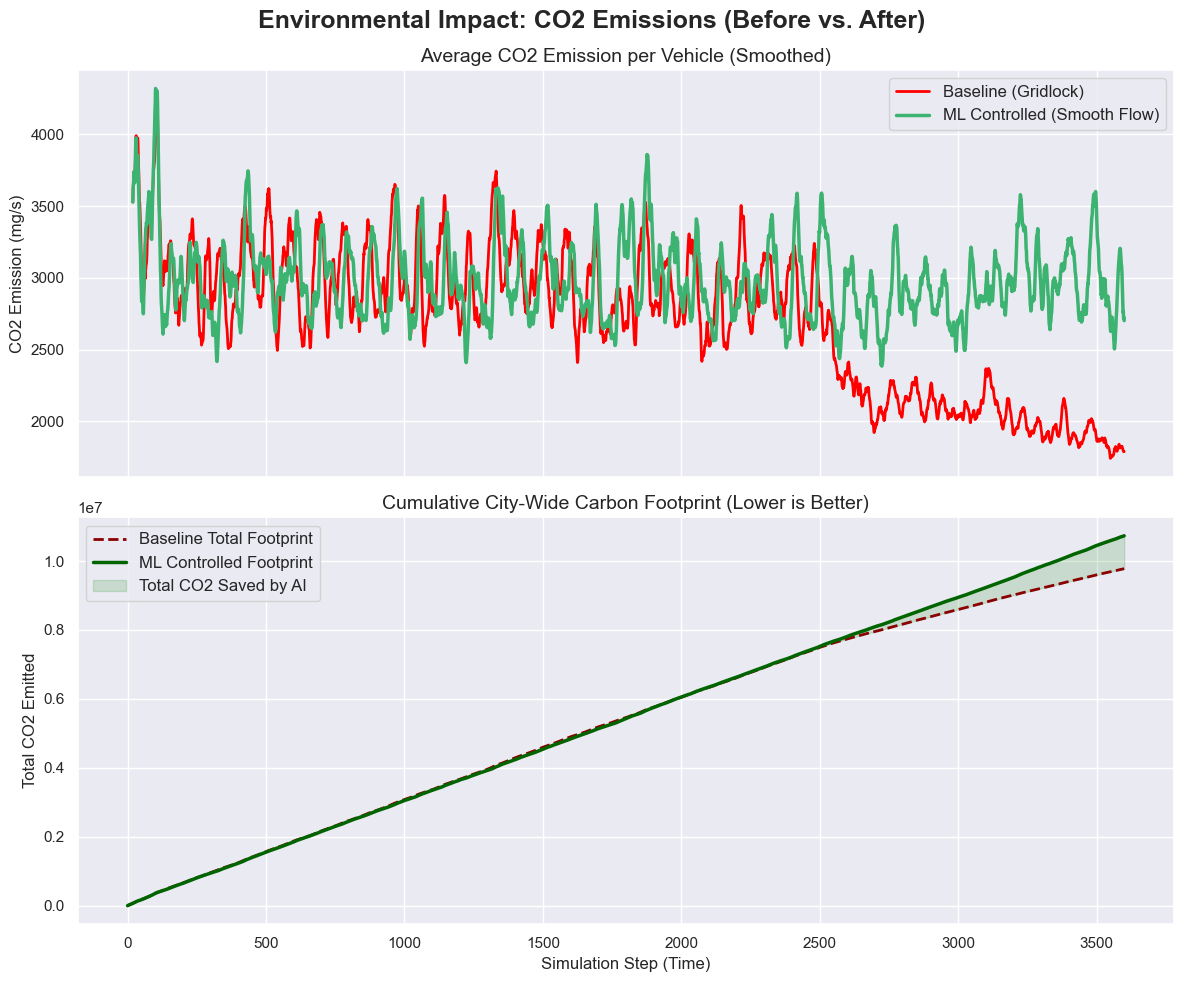

In [11]:
# ==============================
# VISUALIZE ENVIRONMENTAL IMPACT (CO2)
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Generating CO2 Emission Graphs...")

# Load the datasets
try:
    df_base = pd.read_csv("traffic_data.csv")
    df_ml = pd.read_csv("ml_traffic_data.csv")
except FileNotFoundError:
    print("❌ Error: Could not find the CSV files.")

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Environmental Impact: CO2 Emissions (Before vs. After)', fontsize=18, fontweight='bold')

# --- PLOT 1: Smoothed Instantaneous CO2 ---
# We use a rolling window of 20 steps to smooth out the noisy engine data
window_size = 20 
axes[0].plot(df_base['step'], df_base['co2_emission'].rolling(window=window_size).mean(), label='Baseline (Gridlock)', color='red', linewidth=2)
axes[0].plot(df_ml['step'], df_ml['co2_emission'].rolling(window=window_size).mean(), label='ML Controlled (Smooth Flow)', color='mediumseagreen', linewidth=2.5)

axes[0].set_title('Average CO2 Emission per Vehicle (Smoothed)', fontsize=14)
axes[0].set_ylabel('CO2 Emission (mg/s)', fontsize=12)
axes[0].legend(fontsize=12)

# --- PLOT 2: Cumulative CO2 Footprint ---
# cumsum() adds up the emissions step-by-step to show total pollution
axes[1].plot(df_base['step'], df_base['co2_emission'].cumsum(), label='Baseline Total Footprint', color='darkred', linewidth=2, linestyle='--')
axes[1].plot(df_ml['step'], df_ml['co2_emission'].cumsum(), label='ML Controlled Footprint', color='darkgreen', linewidth=2.5)

# Fill the gap to visually represent the "Emissions Saved" by the AI
axes[1].fill_between(df_base['step'], df_base['co2_emission'].cumsum(), df_ml['co2_emission'].cumsum(), color='green', alpha=0.15, label="Total CO2 Saved by AI")

axes[1].set_title('Cumulative City-Wide Carbon Footprint (Lower is Better)', fontsize=14)
axes[1].set_xlabel('Simulation Step (Time)', fontsize=12)
axes[1].set_ylabel('Total CO2 Emitted', fontsize=12)
axes[1].legend(fontsize=12)

# Save and Display
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig("Traffic_AI_Emissions.png", dpi=300)
print("✅ Graph saved successfully as 'Traffic_AI_Emissions.png'")
plt.show()